In [6]:
from ofdm_utils import *

PDP energy = 1.0000000000000002


In [1]:
import matplotlib.pyplot as plt
import numpy as np

In [3]:
import time

In [2]:
from pynq_dpu import DpuOverlay
import xir
import vart
overlay = DpuOverlay("/usr/local/share/pynq-venv/lib/python3.10/site-packages/pynq_dpu/dpu.bit")
overlay.download()
print("DPU overlay loaded:", overlay.is_loaded)
overlay.load_model("/home/xilinx/jupyter_notebooks/cnn_ofdm_estimator.xmodel")

/usr/local/share/pynq-venv/lib/python3.10/site-packages/pynq/ps.py:434: UserWarning: Setting frequency to the closest possible value 98.8879MHz.
  warnings.warn(
/usr/local/share/pynq-venv/lib/python3.10/site-packages/pynq/ps.py:434: UserWarning: Setting frequency to the closest possible value 98.8879MHz.
  warnings.warn(


DPU overlay loaded: <bound method Overlay.is_loaded of <pynq_dpu.dpu.DpuOverlay object at 0xffffa2329030>>


In [3]:
dpu_runner = overlay.runner

shapeIn = tuple(dpu_runner.get_input_tensors()[0].dims)
shapeOut = tuple(dpu_runner.get_output_tensors()[0].dims)
in_tensor  = dpu_runner.get_input_tensors()[0]
out_tensor = dpu_runner.get_output_tensors()[0]

print("INPUT:")
print(" dims      :", in_tensor.dims)
print(" dtype     :", in_tensor.dtype)
print(" fix_point :", in_tensor.get_attr("fix_point"))

print("\nOUTPUT:")
print(" dims      :", out_tensor.dims)
print(" dtype     :", out_tensor.dtype)
print(" fix_point :", out_tensor.get_attr("fix_point"))
input_data  = [np.empty(shapeIn,  dtype=np.int8)]
output_data = [np.empty(shapeOut, dtype=np.int8)]

INPUT:
 dims      : [1, 612, 14, 2]
 dtype     : xint8
 fix_point : 5

OUTPUT:
 dims      : [1, 612, 14, 2]
 dtype     : xint8
 fix_point : 6


In [4]:
# Check input and output scaling
in_fix = dpu_runner.get_input_tensors()[0].get_attr("fix_point")
out_fix = dpu_runner.get_output_tensors()[0].get_attr("fix_point")
INPUT_SCALE  = 2 ** (-in_fix)
OUTPUT_SCALE = 2 ** (-out_fix)
print("in_fix :", in_fix)
print("out_fix:", out_fix)
#print(f"Input needs to be divided by: {2**in_attr}")
#print(f"Output needs to be divided by: {2**out_attr}")

in_fix : 5
out_fix: 6


SNR  0 dB | BER 3.400e-01 | MSE 4.726e+00
SNR  2 dB | BER 2.872e-01 | MSE 2.663e+00
SNR  4 dB | BER 2.419e-01 | MSE 1.776e+00
SNR  6 dB | BER 1.915e-01 | MSE 1.131e+00
SNR  8 dB | BER 1.480e-01 | MSE 6.246e-01
SNR 10 dB | BER 1.050e-01 | MSE 3.901e-01
SNR 12 dB | BER 7.314e-02 | MSE 3.029e-01
SNR 14 dB | BER 3.684e-02 | MSE 1.224e-01
SNR 16 dB | BER 2.876e-02 | MSE 1.374e-01
SNR 18 dB | BER 1.565e-02 | MSE 7.435e-02
SNR 20 dB | BER 1.203e-02 | MSE 5.983e-02
SNR 22 dB | BER 1.008e-02 | MSE 5.088e-02
SNR 24 dB | BER 6.240e-03 | MSE 3.479e-02


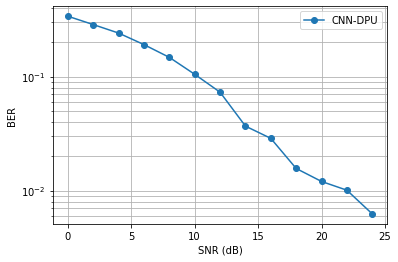

In [14]:
snr_db_list = np.arange(0, 26, 2)
N_mc = 50

ber_mc = []
mse_mc = []

for snr in snr_db_list:
    ber_acc = []
    mse_acc = []

    for mc in range(N_mc):
        bit_stream = random_bits(NUM_DATA_SYMBOLS*4)
        data_symbols, resource_grid = bit_stream_to_resource_grid(bit_stream)
        signal = apply_cyclic_prefix(time_domain_symbols(resource_grid))
        Y, H, noise = transmit(signal, snr)
        noise_var = np.mean(np.abs(noise)**2)
        flattened_preprocessed_symbols, H_estimate = preprocessing_received_signal(Y)
        rx_grid = signal_to_grid(Y)

        # --- CNN → DPU inference ---
        H_split = np.stack((np.real(H_estimate), np.imag(H_estimate)), axis=-1)
        H_batched = np.expand_dims(H_split, axis=0)
        
        # --- Quantize to INT8 ---
        H_int8 = np.round(H_batched / INPUT_SCALE).astype(np.int8)

        # --- DPU buffers ---
        input_tensor  = dpu_runner.get_input_tensors()[0]
        output_tensor = dpu_runner.get_output_tensors()[0]

        in_shape  = tuple(input_tensor.dims)
        out_shape = tuple(output_tensor.dims)

        input_data  = [np.zeros(in_shape, dtype=np.int8)]
        output_data = [np.zeros(out_shape, dtype=np.int8)]

        input_data[0][...] = H_int8

        # --- Execute on DPU ---
        job_id = dpu_runner.execute_async(input_data, output_data)
        dpu_runner.wait(job_id)
        H_pred_int8 = output_data[0]

        H_pred_float = H_pred_int8.astype(np.float32) * OUTPUT_SCALE
        H_pred_single = np.squeeze(H_pred_float, axis=0)  # (612,14,2)
        H_pred_complex = H_pred_single[..., 0] + 1j * H_pred_single[..., 1]

        X_predicted = mmse_equalizer(rx_grid, H_pred_complex, noise_var)
        received_data_symbols = grid_to_data_symbols(X_predicted)

        mse_acc.append(
            calculate_mse(data_symbols, received_data_symbols)
        )

        bits_hat = qam_demapping(received_data_symbols)
        ber_val, _ = calculate_ber(bit_stream, bits_hat)
        ber_acc.append(ber_val)

    ber_mc.append(np.mean(ber_acc))
    mse_mc.append(np.mean(mse_acc))
    print(f"SNR {snr:2d} dB | BER {ber_mc[-1]:.3e} | MSE {mse_mc[-1]:.3e}")

    
plt.semilogy(snr_db_list, ber_mc, 'o-', label="CNN-DPU")
plt.xlabel("SNR (dB)")
plt.ylabel("BER")
plt.grid(True, which="both")
plt.legend()

In [7]:
# For latency measure
snr = 16
bit_stream = random_bits(NUM_DATA_SYMBOLS*4)  # QAM turns 4 bits into a single data symbol
data_symbols, resource_grid = bit_stream_to_resource_grid(bit_stream)
signal = apply_cyclic_prefix(time_domain_symbols(resource_grid))
Y, H, noise = transmit(signal, snr)
noise_var = np.mean(np.abs(noise)**2)
flattened_preprocessed_symbols, H_estimate = preprocessing_received_signal(Y)
rx_grid = signal_to_grid(Y)
H_split = np.stack((np.real(H_estimate), np.imag(H_estimate)), axis=-1)  # shape: (612,14,2)
H_batched = np.expand_dims(H_split, axis=0)   # shape: (1, 612, 14, 2)
# --- Quantize to INT8 ---
H_int8 = np.round(H_batched / INPUT_SCALE).astype(np.int8)

# --- DPU buffers ---
input_tensor  = dpu_runner.get_input_tensors()[0]
output_tensor = dpu_runner.get_output_tensors()[0]

in_shape  = tuple(input_tensor.dims)
out_shape = tuple(output_tensor.dims)

input_data  = [np.zeros(in_shape, dtype=np.int8)]
output_data = [np.zeros(out_shape, dtype=np.int8)]

input_data[0][...] = H_int8

# --- Execute on DPU ---
job_id = dpu_runner.execute_async(input_data, output_data)
dpu_runner.wait(job_id)
job_id = dpu_runner.execute_async(input_data, output_data)
dpu_runner.wait(job_id)



H_pred_int8 = output_data[0]

H_pred_float = H_pred_int8.astype(np.float32) * OUTPUT_SCALE
H_pred_single = np.squeeze(H_pred_float, axis=0)  # (612,14,2)
H_pred_complex = H_pred_single[..., 0] + 1j * H_pred_single[..., 1]

X_predicted = mmse_equalizer(rx_grid, H_pred_complex, noise_var)

received_data_symbols_cnn = grid_to_data_symbols(X_predicted)
mse_cnn_val = calculate_mse(data_symbols, received_data_symbols_cnn)
bits_cnn = qam_demapping(received_data_symbols_cnn)
ber_cnn_val,_ = calculate_ber(bit_stream, bits_cnn)
print("BER:", ber_cnn_val)
print("MSE:", mse_cnn_val)
print("Input int8 range:", H_int8.min(), H_int8.max())
print("Output int8 range:", output_data[0].min(), output_data[0].max())
del dpu_runner

BER: 0.032507739938080496
MSE: 0.09215327021770722
Input int8 range: -54 57
Output int8 range: -93 80


In [18]:
# For latency measure
snr = 16
bit_stream = random_bits(NUM_DATA_SYMBOLS*4)  # QAM turns 4 bits into a single data symbol
data_symbols, resource_grid = bit_stream_to_resource_grid(bit_stream)
signal = apply_cyclic_prefix(time_domain_symbols(resource_grid))
Y, H, noise = transmit(signal, snr)
noise_var = np.mean(np.abs(noise)**2)
flattened_preprocessed_symbols, H_estimate = preprocessing_received_signal(Y)
rx_grid = signal_to_grid(Y)
H_split = np.stack((np.real(H_estimate), np.imag(H_estimate)), axis=-1)  # shape: (612,14,2)
H_batched = np.expand_dims(H_split, axis=0)   # shape: (1, 612, 14, 2)
# --- Quantize to INT8 ---
H_int8 = np.round(H_batched / INPUT_SCALE).astype(np.int8)

# --- DPU buffers ---
input_tensor  = dpu_runner.get_input_tensors()[0]
output_tensor = dpu_runner.get_output_tensors()[0]

in_shape  = tuple(input_tensor.dims)
out_shape = tuple(output_tensor.dims)

input_data  = [np.zeros(in_shape, dtype=np.int8)]
output_data = [np.zeros(out_shape, dtype=np.int8)]

input_data[0][...] = H_int8

# --- Execute on DPU ---
job_id = dpu_runner.execute_async(input_data, output_data)
dpu_runner.wait(job_id)
N = 200
start = time.time()

for _ in range(N):
    job_id = dpu_runner.execute_async(input_data, output_data)
    dpu_runner.wait(job_id)

end = time.time()

latency_ms = (end - start) * 1000 / N
print("Average Latency (ms):", latency_ms)
H_pred_int8 = output_data[0]

H_pred_float = H_pred_int8.astype(np.float32) * OUTPUT_SCALE
H_pred_single = np.squeeze(H_pred_float, axis=0)  # (612,14,2)
H_pred_complex = H_pred_single[..., 0] + 1j * H_pred_single[..., 1]

X_predicted = mmse_equalizer(rx_grid, H_pred_complex, noise_var)

received_data_symbols_cnn = grid_to_data_symbols(X_predicted)
mse_cnn_val = calculate_mse(data_symbols, received_data_symbols_cnn)
bits_cnn = qam_demapping(received_data_symbols_cnn)
ber_cnn_val,_ = calculate_ber(bit_stream, bits_cnn)
print("BER:", ber_cnn_val)
print("MSE:", mse_cnn_val)
print("Input int8 range:", H_int8.min(), H_int8.max())
print("Output int8 range:", output_data[0].min(), output_data[0].max())
del dpu_runner

Average Latency (ms): 1.3036644458770752
BER: 0.013738390092879258
MSE: 0.05088823496259408
Input int8 range: -81 63
Output int8 range: -114 119


In [11]:
# For quantization loss measurement
import numpy as np
import os

snr_vals = [0, 8, 12, 16, 20, 22]

ber_cnn_int8 = []
mse_cnn_int8 = []

for snr in snr_vals:

    print(f"\nProcessing SNR = {snr} dB")

    # -----------------------
    # Load Saved Data
    # -----------------------
    H_input = np.load(f"H_input_snr/H_input_snr_{snr}.npy")          # (612,14,2)
    rx_grid = np.load(f"rx_grid_snr/rx_grid_snr_{snr}.npy")          # complex
    bit_stream = np.load(f"bits_snr/bits_snr_{snr}.npy")
    noise_var = np.load(f"noise_var/noise_var_snr_{snr}.npy")[0]
    data_symbols, _ = bit_stream_to_resource_grid(bit_stream)
    # Add batch dimension
    H_input_batched = np.expand_dims(H_input, axis=0).astype(np.float32)

    # -----------------------
    # DPU Inference
    # -----------------------
    input_tensor = dpu_runner.get_input_tensors()[0]
    output_tensor = dpu_runner.get_output_tensors()[0]

    input_shape = tuple(input_tensor.dims)
    output_shape = tuple(output_tensor.dims)

    input_data = [np.empty(input_shape, dtype=np.float32)]
    output_data = [np.empty(output_shape, dtype=np.float32)]

    input_data[0][0,...] = H_input_batched[0]

    job_id = dpu_runner.execute_async(input_data, output_data)
    dpu_runner.wait(job_id)

    H_pred = output_data[0][0]    # (612,14,2)

    # -----------------------
    # Reconstruct Complex Channel
    # -----------------------
    H_pred_complex = H_pred[...,0] + 1j * H_pred[...,1]

    # -----------------------
    # Equalization
    # -----------------------
    X_equalized = mmse_equalizer(rx_grid, H_pred_complex, noise_var)

    received_data_symbols = grid_to_data_symbols(X_equalized)

    # -----------------------
    # BER and MSE
    # -----------------------
    bits_cnn = qam_demapping(received_data_symbols)
    ber_val, _ = calculate_ber(bit_stream, bits_cnn)

    mse_val = calculate_mse(data_symbols, received_data_symbols)

    ber_cnn_int8.append(ber_val)
    mse_cnn_int8.append(mse_val)

    print(f"SNR={snr} dB => BER_INT8={ber_val:.3e}, MSE_INT8={mse_val:.3e}")


Processing SNR = 0 dB
SNR=0 dB => BER_INT8=3.415e-01, MSE_INT8=4.959e+00

Processing SNR = 8 dB
SNR=8 dB => BER_INT8=1.629e-01, MSE_INT8=9.099e-01

Processing SNR = 12 dB
SNR=12 dB => BER_INT8=6.669e-02, MSE_INT8=1.937e-01

Processing SNR = 16 dB
SNR=16 dB => BER_INT8=2.422e-02, MSE_INT8=7.055e-02

Processing SNR = 20 dB
SNR=20 dB => BER_INT8=3.554e-02, MSE_INT8=1.569e-01

Processing SNR = 22 dB
SNR=22 dB => BER_INT8=1.764e-02, MSE_INT8=1.123e-01
